# Исследовательский анализ данных о бронированиях Яндекс Афиши: сезонные изменения предпочтений и платформенные различия пользователей (июнь–октябрь 2024)

Автор: Ничкова Анжелика

Дата: 12.09.2026

Цель: провести исследовательский анализ данных о бронированиях Яндекс Афиши за июнь–октябрь 2024 года, выявить изменения пользовательских предпочтений и популярности событий осенью, а также проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.

Задачи:

1. Загрузка и предобработка данных.

2. Разведочный анализ данных (EDA).

3. Анализ сезонных изменений предпочтений (лето vs осень).

4. Сравнительный анализ мобильных и десктопных пользователей.

5. Формулировка и проверка статистических гипотез.

6. Обобщение инсайтов и подготовка выводов.

Этапы:

1. Провести предобработку данных: проверить пропуски, дубликаты, типы данных и аномальные значения.
2. Объединить данные о заказах, мероприятиях и курсе валют; привести финансовые показатели к единой валюте.
3. Провести EDA и изучить динамику заказов, пользовательскую активность и ключевые метрики.
4. Сравнить структуру спроса летом и осенью по типам мероприятий, устройствам и возрастным ограничениям.
5. Проанализировать регионы и билетных партнёров по объёму заказов и выручке.
6. Сравнить поведение mobile- и desktop-пользователей и проверить статистические гипотезы.
7. Сформулировать выводы и бизнес-рекомендации.

Описание датасетов:


**orders** — информация о заказах билетов: пользователь, дата заказа, устройство, выручка, количество билетов, интервал с предыдущей покупки.

**events** — информация о мероприятиях: тип события, регион, город, площадка.

**tenge** — данные о курсе тенге к рублю, использованные для приведения финансовых показателей к единой валюте.

## Загрузка данных и знакомство с ними

In [75]:
import pandas as pd
import matplotlib.pyplot as plt 
from scipy import stats#импорт библиотек

In [15]:
orders = pd.read_csv('/Users/lika/Desktop/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/Users/lika/Desktop/datasets/final_tickets_events_df.csv')
tenge  = pd.read_csv('/Users/lika/Desktop/datasets/final_tickets_tenge_df.csv')

In [16]:
for name, data in { #изучим датасеты
    'orders': orders,
    'events': events,
    'tenge': tenge
}.items():
    print(f'\n{name}: {data.shape[0]} строк, {data.shape[1]} столбцов')
    display(data.head())
    data.info()


orders: 290849 строк, 14 столбцов


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 3

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB

tenge: 357 строк, 4 столбцов


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


Загружены три датасета: данные о заказах, событиях и курсе казахстанского тенге. Структура таблиц в целом соответствует описанию. На этапе первичного знакомства видно, что столбцы с датами загружены в строковом формате и требуют преобразования.

In [17]:
orders['created_dt_msk'] = pd.to_datetime( #проверим временные диапазоны
    orders['created_dt_msk'],
    errors='raise')

orders['created_ts_msk'] = pd.to_datetime(
    orders['created_ts_msk'],
    errors='raise')

tenge['data'] = pd.to_datetime(
    tenge['data'],
    errors='raise')

print(
    'Период заказов:',
    orders['created_dt_msk'].min(),
    '—',
    orders['created_dt_msk'].max())

print(
    'Период курсов валют:',
    tenge['data'].min(),
    '—',
    tenge['data'].max())

date_mismatch = (
    orders['created_dt_msk']
    != orders['created_ts_msk'].dt.normalize()).sum()

print('Несоответствий даты и даты-времени:', date_mismatch)

Период заказов: 2024-06-01 00:00:00 — 2024-10-31 00:00:00
Период курсов валют: 2024-01-10 00:00:00 — 2024-12-31 00:00:00
Несоответствий даты и даты-времени: 0


Столбцы `created_dt_msk`, `created_ts_msk` и `data` приведены к типу даты и времени. Даты создания заказов согласованы с датой из временной метки: расхождений между `created_dt_msk` и календарной датой `created_ts_msk` не обнаружено. Таблица курсов покрывает необходимый для анализа период.

## Предобработка данных и подготовка их к исследованию

### Проверка данных на пропуски

In [18]:
#проверка orders на пропуски
print("orders")
print(orders.isna().sum()[orders.isna().sum() > 0])

#проверка events
print("events")
print(events.isna().sum()[events.isna().sum() > 0])

#проверка tenge
print("tenge")
print(tenge.isna().sum()[tenge.isna().sum() > 0])

orders
days_since_prev    21940
dtype: int64
events
Series([], dtype: int64)
tenge
Series([], dtype: int64)


В исходных данных пропуски обнаружены только в столбце `days_since_prev` таблицы заказов — 21 940 значений. Это соответствует описанию данных: пропуск означает отсутствие предыдущей покупки пользователя. В таблицах `events` и `tenge` пропусков нет. Следовательно, выгрузка данных успешна с точки зрения наличия пропусков.

### Изучение значений в ключевых столбцах

In [19]:
order_cat_cols = [ #исследуем категориальные значения
    'cinema_circuit',
    'age_limit',
    'currency_code',
    'device_type_canonical',
    'service_name']

for col in order_cat_cols:
    print(f'\nСтолбец: {col}')
    print('Количество уникальных значений:', orders[col].nunique())
    display(orders[col].value_counts(dropna=False))


Столбец: cinema_circuit
Количество уникальных значений: 6


cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64


Столбец: age_limit
Количество уникальных значений: 5


age_limit
16    78579
12    62557
0     61487
6     52173
18    36053
Name: count, dtype: int64


Столбец: currency_code
Количество уникальных значений: 2


currency_code
rub    285780
kzt      5069
Name: count, dtype: int64


Столбец: device_type_canonical
Количество уникальных значений: 2


device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64


Столбец: service_name
Количество уникальных значений: 36


service_name
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

In [20]:
event_cat_cols = [ #исследуем события
    'event_type_description',
    'event_type_main']

for col in event_cat_cols:
    print(f'\nСтолбец: {col}')
    print('Количество уникальных значений:', events[col].nunique())
    display(events[col].value_counts(dropna=False))


Столбец: event_type_description
Количество уникальных значений: 20


event_type_description
концерт                   8485
спектакль                 6015
событие                   4530
шоу                        731
спортивное мероприятие     575
балет                      484
мюзикл                     359
спорт                      297
опера                      252
фестиваль                  212
выставка                   209
ёлка                       157
цирковое шоу               112
экскурсия                    3
оперетта                     1
рок-мюзикл                   1
музыкальный спектакль        1
снегурочка                   1
подарок                      1
кукольный спектакль          1
Name: count, dtype: int64


Столбец: event_type_main
Количество уникальных значений: 7


event_type_main
концерты    8680
театр       7076
другое      4658
спорт        872
стендап      636
выставки     290
ёлки         215
Name: count, dtype: int64

In [21]:
orders['currency_code'] = ( #проведем нормализацию данных
    orders['currency_code']
    .str.strip()
    .str.lower())

orders['device_type_canonical'] = (
    orders['device_type_canonical']
    .str.strip()
    .str.lower())

orders['cinema_circuit'] = (
    orders['cinema_circuit']
    .str.strip()
    .str.lower())

orders['service_name'] = orders['service_name'].str.strip()

for col in ['event_type_description',
    'event_type_main',
    'organizers',
    'region_name',
    'city_name',
    'venue_name',
    'venue_address']:
    events[col] = events[col].str.strip()

Значения ключевых категориальных признаков изучены. Явных некорректных обозначений пропусков и категорий-дубликатов не обнаружено. Для строковых категорий удалены возможные крайние пробелы, а технические категории `currency_code`, `device_type_canonical` и `cinema_circuit` приведены к единому регистру. Значение 'нет' в `cinema_circuit` не является пропуском: согласно описанию данных, оно означает, что признак сети кинотеатров неприменим.

### Проверка явных и неявных дубликатов

In [22]:
print('Полные дубликаты orders:', orders.duplicated().sum()) #проверка дубликатов
print('Полные дубликаты events:', events.duplicated().sum())
print('Полные дубликаты tenge:', tenge.duplicated().sum())

print()
print('order_id уникален:', orders['order_id'].is_unique)
print('event_id в events уникален:', events['event_id'].is_unique)
print('Дата курса уникальна:', tenge['data'].is_unique)

Полные дубликаты orders: 0
Полные дубликаты events: 0
Полные дубликаты tenge: 0

order_id уникален: True
event_id в events уникален: True
Дата курса уникальна: True


In [23]:
booking_cols = [ #проверим неявные дубликаты
    col for col in orders.columns
    if col != 'order_id'
]

booking_duplicates = orders.duplicated(
    subset=booking_cols,
    keep=False
)

print(
    'Количество строк, участвующих в дублирующихся бронированиях:',
    booking_duplicates.sum()
)

display(
    orders.loc[booking_duplicates]
    .sort_values(['user_id', 'created_ts_msk', 'event_id'])
    .head(20)
)

Количество строк, участвующих в дублирующихся бронированиях: 58


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


In [24]:
duplicates_before = len(orders) #удалим неявные дубликаты

orders = (
    orders
    .drop_duplicates(
        subset=booking_cols,
        keep='first'
    )
    .copy()
)

print(
    'Удалено дублирующихся бронирований:',
    duplicates_before - len(orders)
)

Удалено дублирующихся бронирований: 30


Полных дубликатов не обнаружено, однако при проверке бронирований без учёта уникального order_id были найдены повторяющиеся записи. Они совпадают по характеристикам заказа и отличаются только идентификатором заказа, поэтому были интерпретированы как дублирующиеся бронирования. Для каждой группы сохранена одна запись.

count    287932.000000
mean          2.739914
std           1.162294
min           1.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

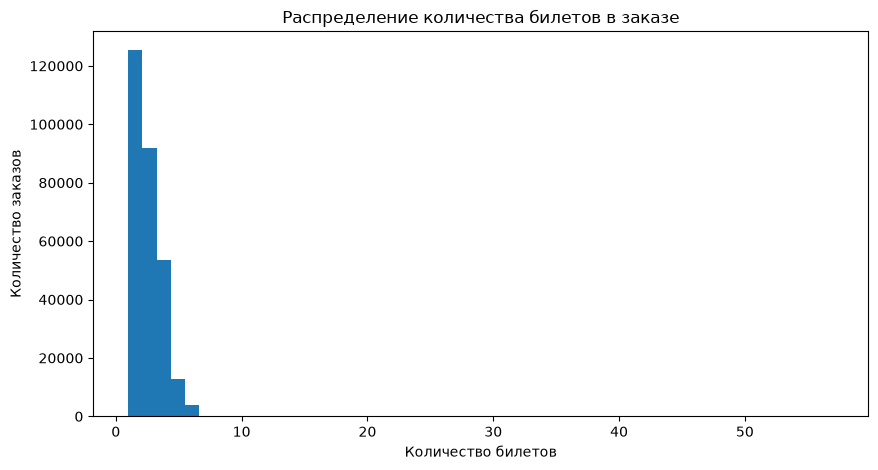

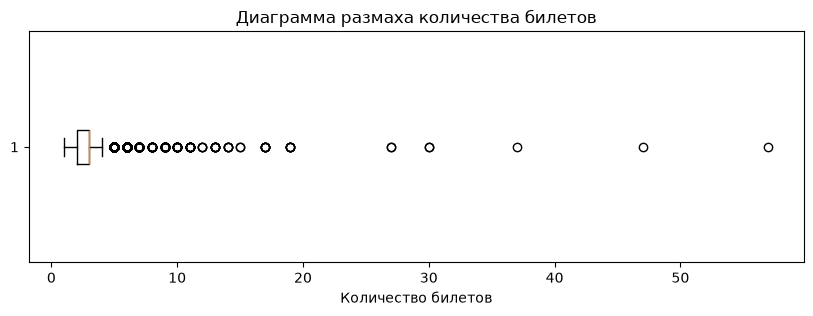

In [78]:
display( #посмотрим на распределение количества билетов в заказе
    orders['tickets_count']
    .describe(percentiles=[0.95, 0.99])
)

plt.figure(figsize=(10, 5))
plt.hist(orders['tickets_count'], bins=50)
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')
plt.show()

plt.figure(figsize=(10, 3))
plt.boxplot(orders['tickets_count'], orientation='horizontal')
plt.title('Диаграмма размаха количества билетов')
plt.xlabel('Количество билетов')
plt.show()

In [77]:
display(
    orders
    .groupby('currency_code')['revenue']
    .describe(percentiles=[0.95, 0.99])
)

,count,mean,std,min,95%,99%,max
currency_code,,,,,,,
kzt,5040.0,4893.669063,4742.680176,0.00,13784.26,17617.24,17617.24
rub,282892.0,509.985825,500.116359,-90.76,1541.75,2091.31,2569.59


In [27]:
print('revenue = 0:', (orders['revenue'] == 0).sum()) #проверим количество этих значений
print('revenue < 0:', (orders['revenue'] < 0).sum())

display(
    orders.loc[orders['revenue'] < 0, [
        'order_id',
        'created_dt_msk',
        'currency_code',
        'revenue',
        'total',
        'tickets_count',
        'service_name'
    ]]
)

revenue = 0: 5736
revenue < 0: 381


,order_id,created_dt_msk,currency_code,revenue,total,tickets_count,service_name
264,1594653,2024-06-29,rub,-2.37,-59.20,3,Билеты без проблем
4540,2360920,2024-09-03,rub,-0.23,-7.65,3,Билеты без проблем
4562,2361094,2024-09-04,rub,-0.15,-5.10,2,Билеты без проблем
8155,166809,2024-09-27,rub,-0.62,-20.64,1,Лучшие билеты
8156,166780,2024-09-27,rub,-1.86,-61.92,3,Лучшие билеты
...,...,...,...,...,...,...,...
289083,3700575,2024-10-12,rub,-5.70,-71.24,1,Тебе билет!
289152,3523617,2024-10-15,rub,-0.96,-31.84,2,Лучшие билеты
289153,3523646,2024-10-15,rub,-1.43,-47.76,3,Лучшие билеты
289303,5445853,2024-10-21,rub,-0.61,-15.36,1,Лучшие билеты


In [28]:
print(
    'Отрицательный revenue и неотрицательный total:',
    ((orders['revenue'] < 0) & (orders['total'] >= 0)).sum()
)

print(
    'Отрицательный revenue и tickets_count <= 0:',
    ((orders['revenue'] < 0) & (orders['tickets_count'] <= 0)).sum()
)

Отрицательный revenue и неотрицательный total: 0
Отрицательный revenue и tickets_count <= 0: 0


В столбце `revenue` обнаружены нулевые и отрицательные значения: 5 736 заказов имеют нулевую выручку, ещё 381 заказ — отрицательную. Для заказов с отрицательной выручкой значение `total` также отрицательное, при этом количество билетов остаётся положительным. Такая согласованность показателей указывает на то, что значения могут отражать возвраты или корректировки, а не ошибки в данных. Поэтому нулевые и отрицательные значения были сохранены. Дальнейшая обработка выбросов проводилась только для аномально высоких значений `revenue`.

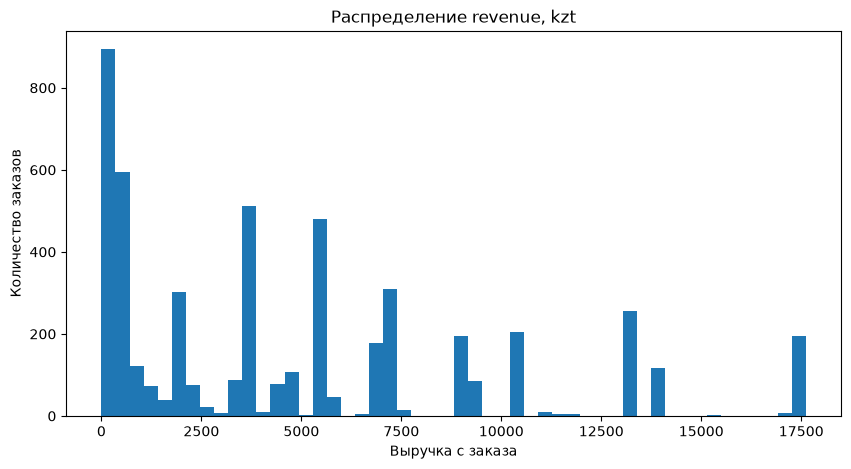

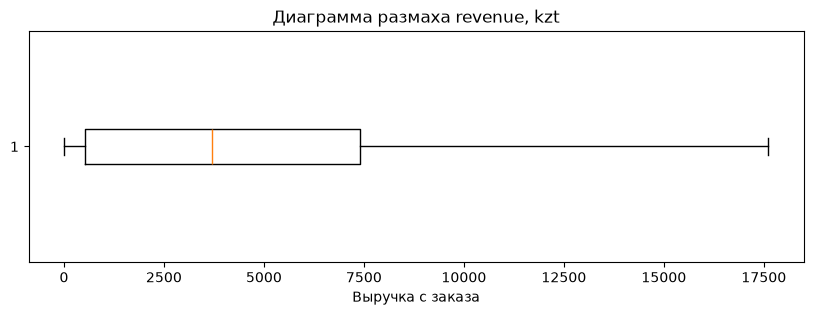

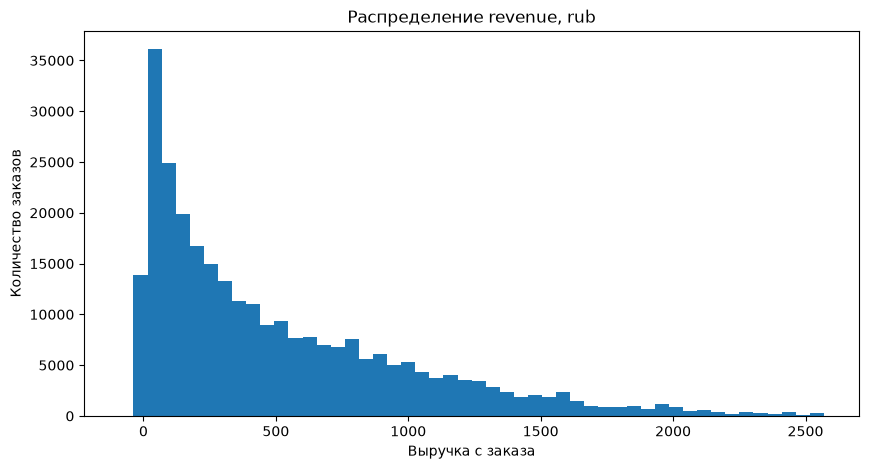

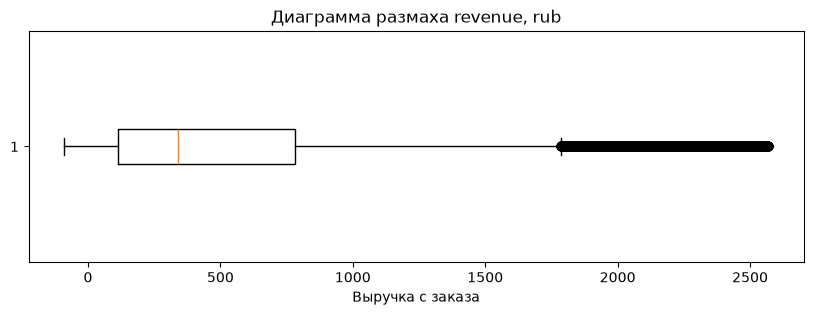

In [79]:
for currency in sorted(orders['currency_code'].unique()): #рассмотрим распределение выручки
    revenue_part = orders.loc[
        orders['currency_code'] == currency,
        'revenue'
    ]

    plt.figure(figsize=(10, 5))
    plt.hist(revenue_part, bins=50)
    plt.title(f'Распределение revenue, {currency}')
    plt.xlabel('Выручка с заказа')
    plt.ylabel('Количество заказов')
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.boxplot(revenue_part, orientation='horizontal')
    plt.title(f'Диаграмма размаха revenue, {currency}')
    plt.xlabel('Выручка с заказа')
    plt.show()

Количество билетов в заказе имеет правостороннее распределение: 99% заказов содержат не более 6 билетов, при этом максимальное значение достигает 57. Такие крупные заказы могут быть реальными групповыми покупками, поэтому дополнительные ограничения для `tickets_count` не вводились.

Распределение revenue также имеет выраженный правый хвост. Поскольку заказы представлены в разных валютах, выбросы определялись отдельно для RUB и KZT. Значение 99-го процентиля составило 2 569,60 RUB и 17 617,24 KZT соответственно. Значения выше этих границ были исключены; всего удалено 2 887 заказов, или около 0,99% данных.

In [30]:
revenue_q99 = ( #исследуем данные на выбросы по 99 процентилю
    orders
    .groupby('currency_code')['revenue']
    .quantile(0.99)
)

display(revenue_q99)

currency_code
kzt    17617.2400
rub     2569.6002
Name: revenue, dtype: float64

In [31]:
orders = orders.join( #удаляем выбросы выше порога для каждой валюты
    revenue_q99.rename('revenue_q99'),
    on='currency_code')

revenue_outliers = (
    orders['revenue']
    > orders['revenue_q99'])

print(
    'Количество выбросов revenue:',
    revenue_outliers.sum())

print(
    f'Доля выбросов: {revenue_outliers.mean():.2%}')

orders = (
    orders.loc[~revenue_outliers]
    .drop(columns='revenue_q99')
    .copy())

Количество выбросов revenue: 2887
Доля выбросов: 0.99%


In [32]:
daily_rates = ( #подготовим ежедневный курс
    tenge
    .set_index('data')[['nominal', 'curs']]
    .reindex(
        pd.date_range(
            tenge['data'].min(),
            tenge['data'].max(),
            freq='D'
        )
    )
    .ffill()
)

daily_rates.index.name = 'created_dt_msk'
daily_rates = daily_rates.reset_index()

In [33]:
orders = orders.merge(  #рассмотрим заказы без курса kzt
    daily_rates,
    on='created_dt_msk',
    how='left',
    validate='many_to_one'
)

kzt_mask = orders['currency_code'].eq('kzt')

print(
    'Заказов KZT без курса:',
    orders.loc[kzt_mask, 'curs'].isna().sum()
)

Заказов KZT без курса: 0


In [34]:
orders['revenue_rub'] = orders['revenue'] #проведем пересчет денежных значений из тенге в рубли
orders['total_rub'] = orders['total']

orders.loc[kzt_mask, 'revenue_rub'] = (
    orders.loc[kzt_mask, 'revenue']
    * orders.loc[kzt_mask, 'curs']
    / orders.loc[kzt_mask, 'nominal']
)

orders.loc[kzt_mask, 'total_rub'] = (
    orders.loc[kzt_mask, 'total']
    * orders.loc[kzt_mask, 'curs']
    / orders.loc[kzt_mask, 'nominal']
)

display(
    orders.loc[
        kzt_mask,
        [
            'created_dt_msk',
            'currency_code',
            'revenue',
            'revenue_rub',
            'total',
            'total_rub'
        ]
    ].head()
)

,created_dt_msk,currency_code,revenue,revenue_rub,total,total_rub
73,2024-09-17,kzt,518.10,98.503762,10361.97,1970.069546
91,2024-09-02,kzt,347.18,65.731589,6943.61,1314.633681
98,2024-09-09,kzt,328.77,61.148261,10959.07,2038.288388
465,2024-06-04,kzt,7397.66,1478.296591,123294.32,24638.273849
466,2024-06-04,kzt,3698.83,739.148295,61647.16,12319.136924


In [35]:
orders = orders.drop(
    columns=['nominal', 'curs'])

Для дальнейшего сопоставимого анализа денежные показатели приведены к российским рублям. Для заказов в тенге использован курс на соответствующую дату; поскольку курс указан за 100 KZT, при пересчёте сумма в тенге умножалась на curs / nominal. Созданы столбцы revenue_rub и total_rub, при этом исходные денежные значения и информация о валюте сохранены.

In [36]:
# создадим столбцы "выручка с одного билета в рублях"
orders['one_ticket_revenue_rub'] = (
    orders['revenue_rub'] / orders['tickets_count']
)

# "месяц оформления заказа"
orders['month'] = orders['created_dt_msk'].dt.month

# "сезон оформления заказа"
season_map = {
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}

orders['season'] = orders['month'].map(season_map)

In [37]:
display( #проверим созданные столбцы
    orders[
        [
            'created_dt_msk',
            'revenue_rub',
            'tickets_count',
            'one_ticket_revenue_rub',
            'month',
            'season'
        ]
    ].head()
)

print(orders['season'].value_counts())

,created_dt_msk,revenue_rub,tickets_count,one_ticket_revenue_rub,month,season
0,2024-08-20,1521.94,4,380.4850,8,лето
1,2024-07-23,289.45,2,144.7250,7,лето
2,2024-10-06,1258.57,4,314.6425,10,осень
3,2024-07-13,8.49,2,4.2450,7,лето
4,2024-10-04,1390.41,3,463.4700,10,осень


season
осень    168607
лето     119325
Name: count, dtype: int64


In [38]:
df = orders.merge( #соеденим датасеты
    events,
    on='event_id',
    how='left',
    validate='many_to_one',
    indicator=True)

display(df['_merge'].value_counts())

_merge
both          287694
left_only        238
right_only         0
Name: count, dtype: int64

In [39]:
no_event_mask = df['_merge'].eq('left_only') #проверим заказы без события

print(
    'Заказов без соответствующего события:',
    no_event_mask.sum())

print(
    f'Доля таких заказов: {no_event_mask.mean():.4%}')

display(
    df.loc[
        no_event_mask,
        [
            'order_id',
            'event_id',
            'cinema_circuit',
            'service_name'
        ]
    ].head(10))

Заказов без соответствующего события: 238
Доля таких заказов: 0.0827%


,order_id,event_id,cinema_circuit,service_name
62,6493246,533222,нет,Билеты в руки
63,6493275,533222,нет,Билеты в руки
64,6493304,533222,нет,Билеты в руки
234,8272280,530296,нет,Билеты без проблем
235,8272512,530296,нет,Билеты без проблем
236,8272251,530296,нет,Билеты без проблем
237,8272338,530296,нет,Билеты без проблем
238,8272367,530296,нет,Билеты без проблем
239,8272396,530296,нет,Билеты без проблем
240,8272425,530296,нет,Билеты без проблем


Проведем фильтрацию объединённого датафрейма df: она удаляет строки, для которых не нашлось события в `events`, а затем убирает технический столбец `_merge`.

In [40]:
df = ( #фильтрация
    df.loc[~no_event_mask]
    .drop(columns='_merge')
    .copy()
)

In [41]:
df['city_id'] = df['city_id'].astype('int32') #преобразуем стообцы к нужным типам данных
df['venue_id'] = df['venue_id'].astype('int32')

print(df[['city_id', 'venue_id']].dtypes)

city_id     int32
venue_id    int32
dtype: object


После объединения часть заказов не получила признаков из таблицы  `events`. Это ожидаемый результат: таблица заказов содержит все заказы, тогда как фильмы были исключены из датасета событий. Доля таких заказов составляет 0.0827%. Поскольку дальнейшее исследование категорий событий, организаторов и площадок невозможно без данных из events, эти строки исключены из объединённого датасета. При этом предобработанная таблица orders сохранена отдельно и по-прежнему содержит информацию обо всех остальных корректных заказах после обработки выбросов и дубликатов.

In [42]:
memory_before = df.memory_usage(deep=True).sum() / 1024**2 #понизим разрядность

int_cols = df.select_dtypes(include='integer').columns

for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

df['days_since_prev'] = pd.to_numeric(
    df['days_since_prev'],
    downcast='float'
)

memory_after = df.memory_usage(deep=True).sum() / 1024**2

print(f'Память до оптимизации: {memory_before:.2f} МБ')
print(f'Память после оптимизации: {memory_after:.2f} МБ')

df.info()

Память до оптимизации: 418.68 МБ
Память после оптимизации: 410.18 МБ
<class 'pandas.DataFrame'>
Index: 287694 entries, 0 to 287931
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287694 non-null  int32         
 1   user_id                 287694 non-null  str           
 2   created_dt_msk          287694 non-null  datetime64[us]
 3   created_ts_msk          287694 non-null  datetime64[us]
 4   event_id                287694 non-null  int32         
 5   cinema_circuit          287694 non-null  str           
 6   age_limit               287694 non-null  int8          
 7   currency_code           287694 non-null  str           
 8   device_type_canonical   287694 non-null  str           
 9   revenue                 287694 non-null  float64       
 10  service_name            287694 non-null  str           
 11  tickets_count           287694 non-nul

In [43]:
print('Размер итогового датасета:', df.shape) #проверим итоговый df 

print(
    'Полных дубликатов:',
    df.duplicated().sum()
)

print(
    'Повторяющихся order_id:',
    df['order_id'].duplicated().sum()
)

print('\nПропуски:')
display(
    df.isna().sum()[
        df.isna().sum() > 0
    ]
)

print(
    '\nПериод:',
    df['created_dt_msk'].min(),
    '—',
    df['created_dt_msk'].max()
)

print(
    '\nВалюты:',
    df['currency_code'].unique()
)

print(
    'Устройства:',
    df['device_type_canonical'].unique()
)

display(df.head())

Размер итогового датасета: (287694, 29)
Полных дубликатов: 0
Повторяющихся order_id: 0

Пропуски:


days_since_prev    21706
dtype: int64


Период: 2024-06-01 00:00:00 — 2024-10-31 00:00:00

Валюты: <StringArray>
['rub', 'kzt']
Length: 2, dtype: str
Устройства: <StringArray>
['mobile', 'desktop']
Length: 2, dtype: str


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


В ходе предобработки данные были проверены на пропуски, дубликаты, некорректные значения и выбросы. Пропуски обнаружены только в столбце `days_since_prev`, что соответствует описанию данных. Также были изучены значения категориальных признаков и выполнена их нормализация там, где это было необходимо.

Явные дубликаты не выявлены. При проверке неявных дубликатов бронирований без учёта идентификатора заказа были обнаружены повторяющиеся записи, после удаления которых количество строк сократилось с 290 849 до 290 819.

Распределения количественных показателей были изучены отдельно для количества билетов и выручки. Для `revenue` выбросы анализировались отдельно для рублей и тенге, так как исходные данные представлены в разных валютах. Были рассчитаны 99-е процентили: 2569,60 руб. для заказов в RUB и 17 617,24 тенге для заказов в KZT. Значения выше этих границ были исключены из анализа. После фильтрации осталось 287 932 заказа.

Данные о заказах были объединены с информацией о событиях. Заказы, для которых не удалось найти соответствующее событие, были исключены. После объединения и фильтрации в итоговом датафрейме осталось 287 694 строки, что составляет около 98,9% от первоначального объёма данных.

Типы данных были приведены к более подходящим форматам: даты и время преобразованы в `datetime`, а идентификаторы и количественные признаки — в подходящие числовые типы.

Для дальнейшего анализа были созданы новые признаки:

* `revenue_rub` — выручка с заказа, приведённая к российским рублям с использованием курса тенге;
* `one_ticket_revenue_rub` — средняя выручка с одного проданного билета;
* `month` — месяц оформления заказа;
* `season` — сезон оформления заказа.

Данные очищены, приведены к единому формату и подготовлены для дальнейшего исследовательского анализа.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

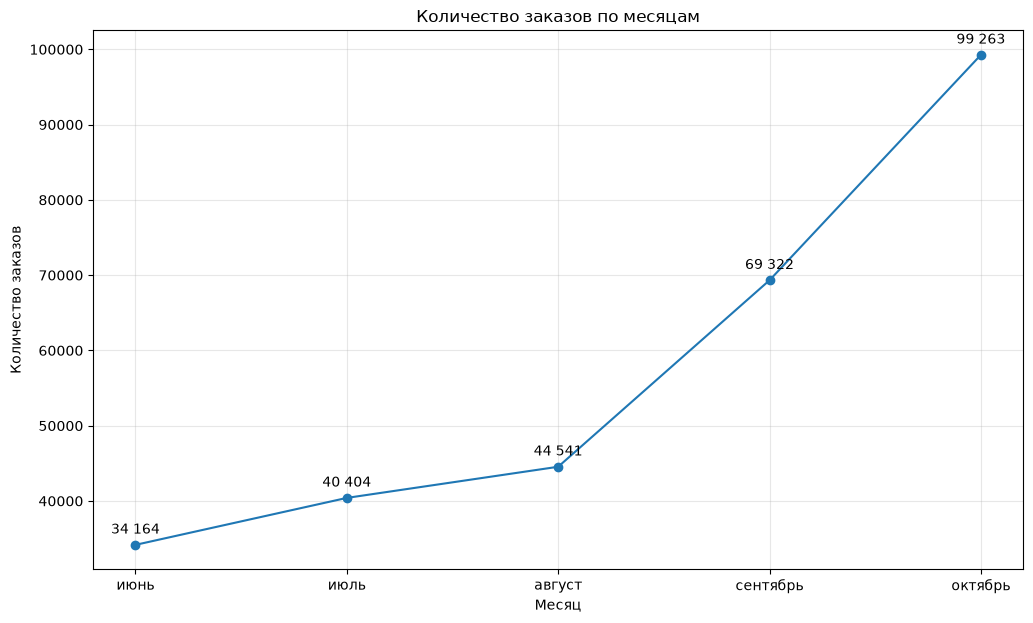

In [44]:
#посчитаем и визуализируем количество заказов по месяцам
monthly_orders = (
    df.groupby('month')['order_id']
    .nunique())
month_names = ['июнь', 'июль', 'август', 'сентябрь', 'октябрь']

plt.figure(figsize=(12, 7))
plt.plot(
    month_names,
    monthly_orders.values,
    marker='o')

for month, value in zip(month_names, monthly_orders.values):

    plt.text(
        month,
        value + 1500,
        f'{value:,}'.replace(',', ' '),
        ha='center')
    
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

Количество заказов последовательно увеличивается на протяжении всего исследуемого периода: с 34,2 тыс. в июне до 99,3 тыс. в октябре. Особенно заметный рост начинается с сентября: количество заказов увеличивается с 44,5 тыс. в августе до 69,3 тыс. в сентябре и 99,3 тыс. в октябре. Таким образом, данные подтверждают рост пользовательской активности с наступлением осени.

In [45]:
def season_share(data, column): #для удобства напишем функцию, которая считает доли заказов по категории летом и осенью
    temp = (
        data[data['season'].isin(['лето', 'осень'])]
        .groupby(['season', column])['order_id']
        .nunique()
        .reset_index(name='orders_count'))

    temp['share'] = (
        temp.groupby('season')['orders_count']
        .transform(lambda x: x / x.sum() * 100))

    result = (
        temp.pivot(
            index=column,
            columns='season',
            values='share')
        .fillna(0)
        .reindex(columns=['лето', 'осень']))
    return result

season,лето,осень
event_type_main,,
выставки,2.03,1.44
другое,27.18,19.71
концерты,42.61,37.19
спорт,2.52,11.20
стендап,5.33,4.11
театр,20.10,25.35
ёлки,0.23,1.00


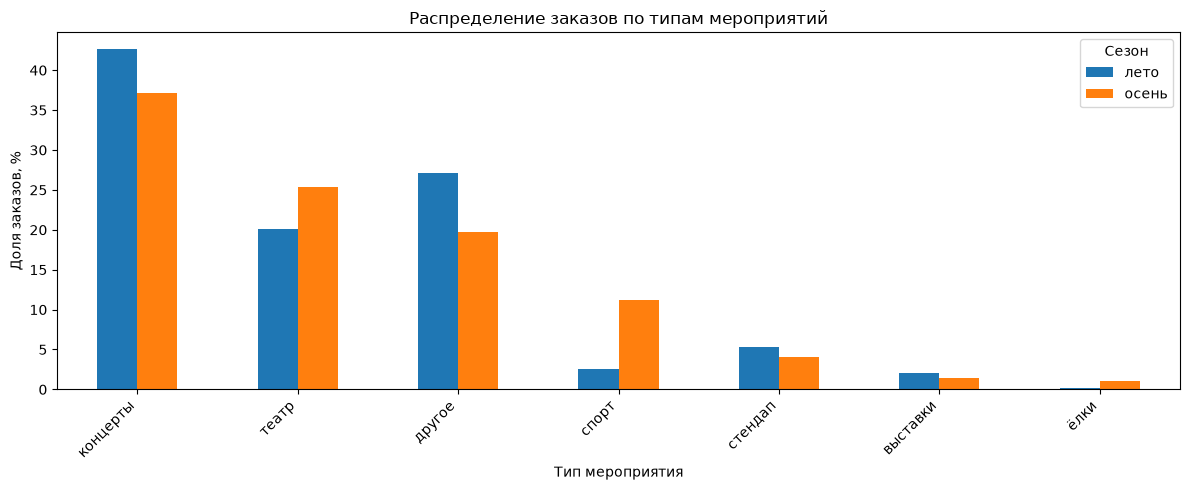

In [46]:
event_type_share = season_share(df, 'event_type_main') # посичтаем и визуализируем распределение заказов по типам мероприятий
display(event_type_share.round(2))

event_type_share = event_type_share.sort_values(by = 'осень', ascending = False)
event_type_share.plot(
    kind='bar',
    figsize=(12, 5))

plt.title('Распределение заказов по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Сезон')
plt.tight_layout()

plt.show()

Структура заказов по типам мероприятий заметно меняется с наступлением осени. Концерты остаются самой популярной категорией, однако их доля снижается с 42,61% летом до 37,19% осенью. Также уменьшается доля категории «другое» — с 27,18% до 19,71%.

Наиболее выраженный рост наблюдается у спортивных мероприятий: их доля увеличивается с 2,52% до 11,20%. Доля театральных мероприятий также возрастает — с 20,10% до 25,35%. Небольшой рост наблюдается у ёлок — с 0,23% до 1,00%. Таким образом, осенью структура спроса смещается в сторону спорта и театра, при этом концерты хотя и сохраняют лидерство, занимают меньшую долю заказов.

season,лето,осень
device_type_canonical,,
desktop,19.36,20.35
mobile,80.64,79.65


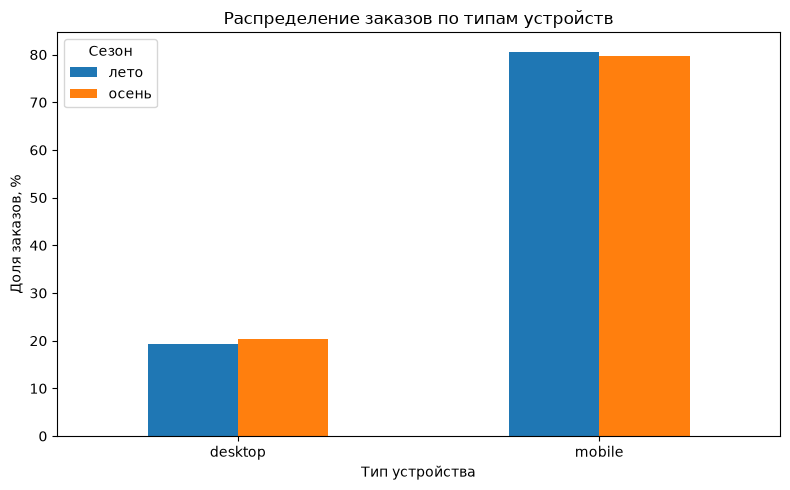

In [47]:
device_share = season_share(df, 'device_type_canonical') # посичтаем и визуализируем распределение заказов по типам устройств

display(device_share.round(2))

device_share.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Распределение заказов по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend(title='Сезон')
plt.tight_layout()

plt.show()

Распределение заказов по типам устройств практически не меняется между сезонами. На мобильные устройства приходится около 80% заказов как летом, так и осенью: доля mobile снижается лишь с 80,64% до 79,65%, а доля desktop увеличивается с 19,36% до 20,35%.

Следовательно, осенний рост количества заказов нельзя объяснить существенным изменением структуры пользователей по типу устройства: мобильный канал остаётся доминирующим в обоих сезонах.

season,лето,осень
0+,17.97,23.62
6+,18.20,17.63
12+,20.53,22.08
16+,28.34,26.23
18+,14.96,10.44


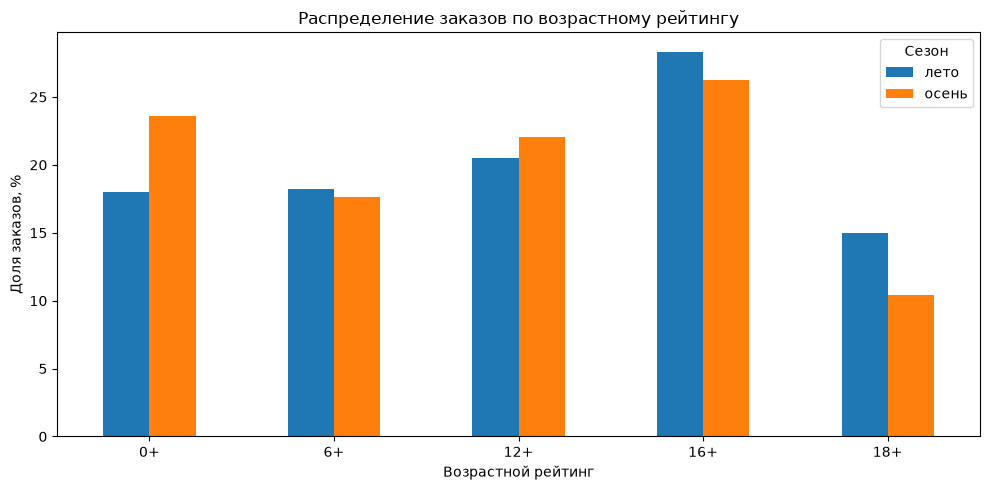

In [48]:
age_share = season_share(df, 'age_limit')
age_share.index = [f'{x}+' for x in age_share.index] # посичтаем и визуализируем распределение заказов по возрастному рейтингу

display(age_share.round(2))

age_share.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Распределение заказов по возрастному рейтингу')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend(title='Сезон')
plt.tight_layout()

plt.show()

С наступлением осени меняется и распределение заказов по возрастным рейтингам. Наиболее заметно увеличивается доля мероприятий 0+ — с 17,97% летом до 23,62% осенью. Доля категории 12+ также возрастает с 20,53% до 22,08%.

Одновременно сокращается доля заказов на мероприятия 18+ — с 14,96% до 10,44%, а категория 16+ снижается с 28,34% до 26,23%. Категория 6+ остаётся практически без изменений. Это указывает на осеннее смещение структуры спроса в сторону мероприятий с более низкими возрастными ограничениями.

In [49]:
ticket_revenue_by_type = ( #посчитаем изменение выручки осенью относительно лета
    df[df['season'].isin(['лето', 'осень'])]
    .groupby(['event_type_main', 'season'])['one_ticket_revenue_rub']
    .mean()
    .unstack()
    .reindex(columns=['лето', 'осень']))

ticket_revenue_by_type['change_pct'] = ((ticket_revenue_by_type['осень']
        / ticket_revenue_by_type['лето']
        - 1)* 100)

display(ticket_revenue_by_type.round(2))

season,лето,осень,change_pct
event_type_main,,,
выставки,86.42,90.60,4.85
другое,77.43,76.12,-1.70
концерты,304.72,268.08,-12.02
спорт,50.76,49.97,-1.56
стендап,218.52,231.12,5.77
театр,214.13,175.97,-17.82
ёлки,271.44,229.59,-15.42


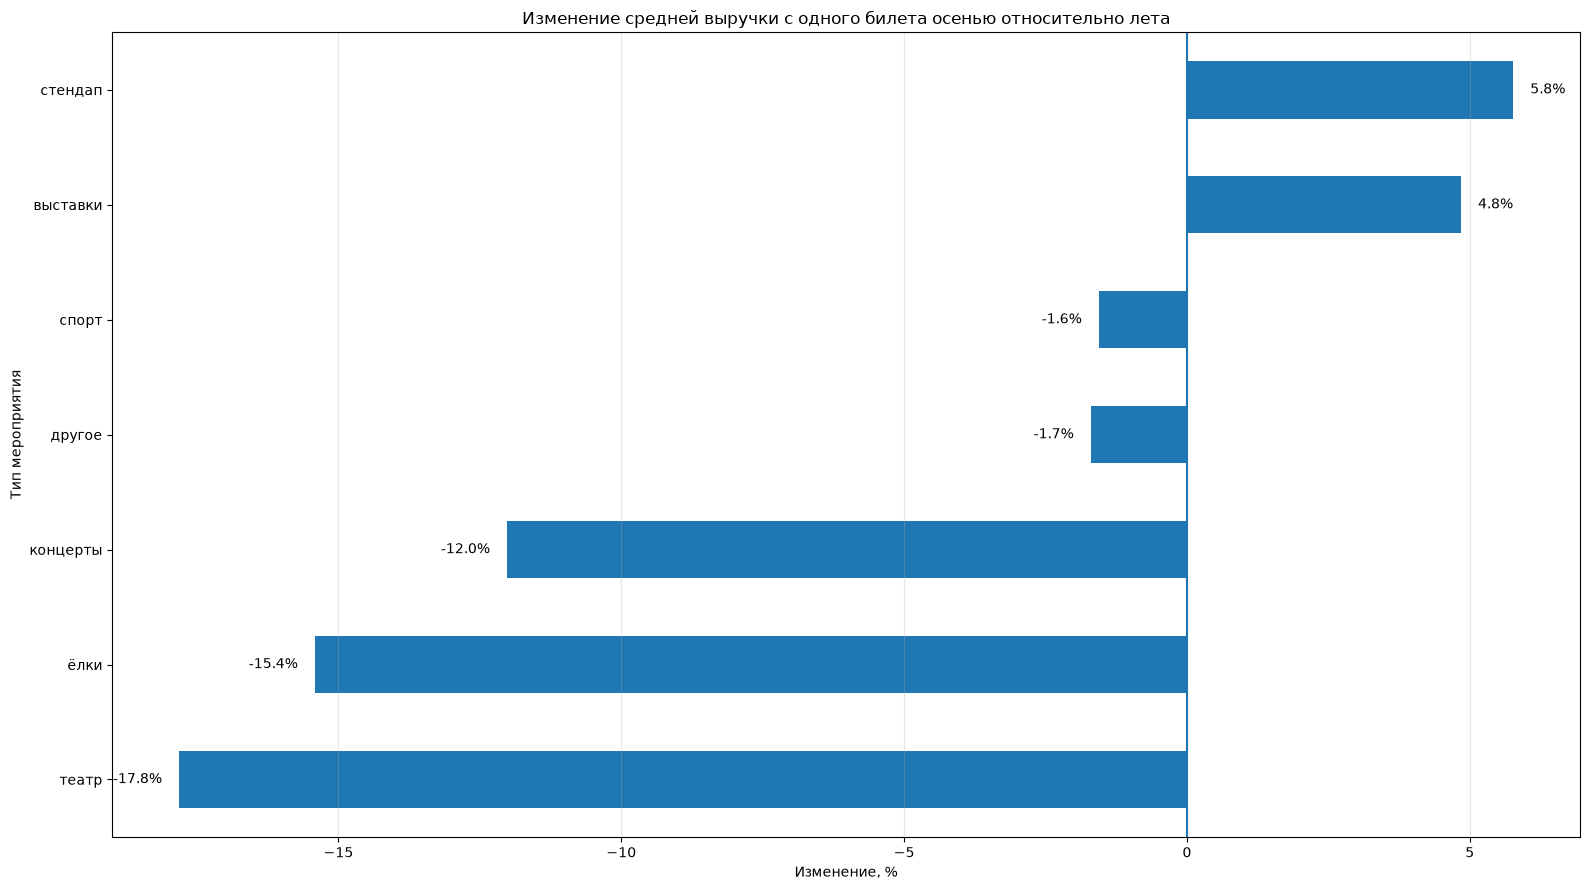

In [50]:
change = ticket_revenue_by_type['change_pct'].sort_values() #визуализируем изменение выручки осенью относительно лета
ax = change.plot(
    kind='barh',
    figsize=(16, 9))

plt.title('Изменение средней выручки с одного билета осенью относительно лета')
plt.xlabel('Изменение, %')
plt.ylabel('Тип мероприятия')
plt.axvline(0)
plt.grid(axis='x', alpha=0.3)

for i, value in enumerate(change):
    plt.text(
        value + (0.3 if value >= 0 else -0.3),
        i,
        f'{value:.1f}%',
        va='center',
        ha='left' if value >= 0 else 'right')

plt.tight_layout()
plt.show()

Средняя выручка с одного билета осенью изменяется по-разному в зависимости от типа мероприятия. Рост наблюдается только у стендапа (+5,77%) и выставок (+4,85%). Для спорта и категории «другое» изменение невелико и составляет около −1,5–1,7%.

Наиболее заметное снижение приходится на театральные мероприятия: средняя выручка с одного билета уменьшается на 17,82%. Также существенно снижается показатель у ёлок (−15,42%) и концертов (−12,02%). При этом концерты сохраняют наиболее высокую среднюю выручку с одного билета среди рассматриваемых категорий — 268,08 руб. осенью.

Таким образом, рост общего количества заказов осенью не сопровождается одновременным ростом средней выручки с одного билета во всех категориях. Для ряда крупных сегментов показатель, напротив, снижается.

**Промежуточный вывод:**

В исследуемом периоде наблюдается выраженная сезонная динамика пользовательской активности. Количество заказов последовательно растёт с 34,2 тыс. в июне до 99,3 тыс. в октябре, причём особенно заметное ускорение начинается в сентябре. Это подтверждает предположение о росте спроса с наступлением осени.

Вместе с ростом числа заказов меняется и структура спроса. Осенью значительно увеличивается доля спортивных мероприятий — с 2,52% до 11,20%, а также театра — с 20,10% до 25,35%. При этом концерты остаются крупнейшей категорией, но их доля сокращается с 42,61% до 37,19%. В возрастной структуре увеличивается доля мероприятий 0+ и 12+, тогда как доля 18+ и 16+ снижается.

Структура заказов по устройствам практически стабильна: около 80% покупок совершается с мобильных устройств как летом, так и осенью. Поэтому сезонный рост активности скорее связан с изменением спроса на категории мероприятий, чем с изменением соотношения мобильных и десктопных пользователей.

При этом рост количества заказов не означает роста выручки с одного билета. Осенью средний показатель существенно снижается для театра (−17,82%), ёлок (−15,42%) и концертов (−12,02%), тогда как рост наблюдается у стендапа (+5,77%) и выставок (+4,85%). Таким образом, осенний рост рынка в рассматриваемых данных прежде всего проявляется в увеличении объёма заказов и изменении структуры спроса, а не в общем повышении выручки с одного билета.

С бизнес-точки зрения сервису стоит учитывать сезонное перераспределение интереса при формировании осенних подборок и продвижении мероприятий. Осенью особенно перспективно усиливать видимость спортивных и театральных событий, сохраняя при этом активное продвижение концертов как крупнейшей категории. Стабильно высокая доля мобильных заказов также показывает, что мобильный канал остаётся ключевой точкой взаимодействия с пользователями. Снижение выручки с одного билета в нескольких крупных категориях стоит учитывать отдельно: рост количества заказов не обязательно приводит к пропорциональному росту денежного результата на один проданный билет.





### Анализ осенней активности пользователей

In [51]:
#фильтруем данные за два осенних месяца
autumn = df[df['month'].isin([9, 10])].copy()

In [52]:
daily_activity = ( #сводная таблица по дням
    autumn
    .groupby('created_dt_msk')
    .agg(
        orders_count=('order_id', 'nunique'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')).reset_index())

daily_activity['orders_per_user'] = (
    daily_activity['orders_count'] / daily_activity['dau'])

display(daily_activity.head())

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5111,778,80.130097,6.569409
3,2024-09-04,1772,685,177.785850,2.586861
4,2024-09-05,1944,739,189.510156,2.630582


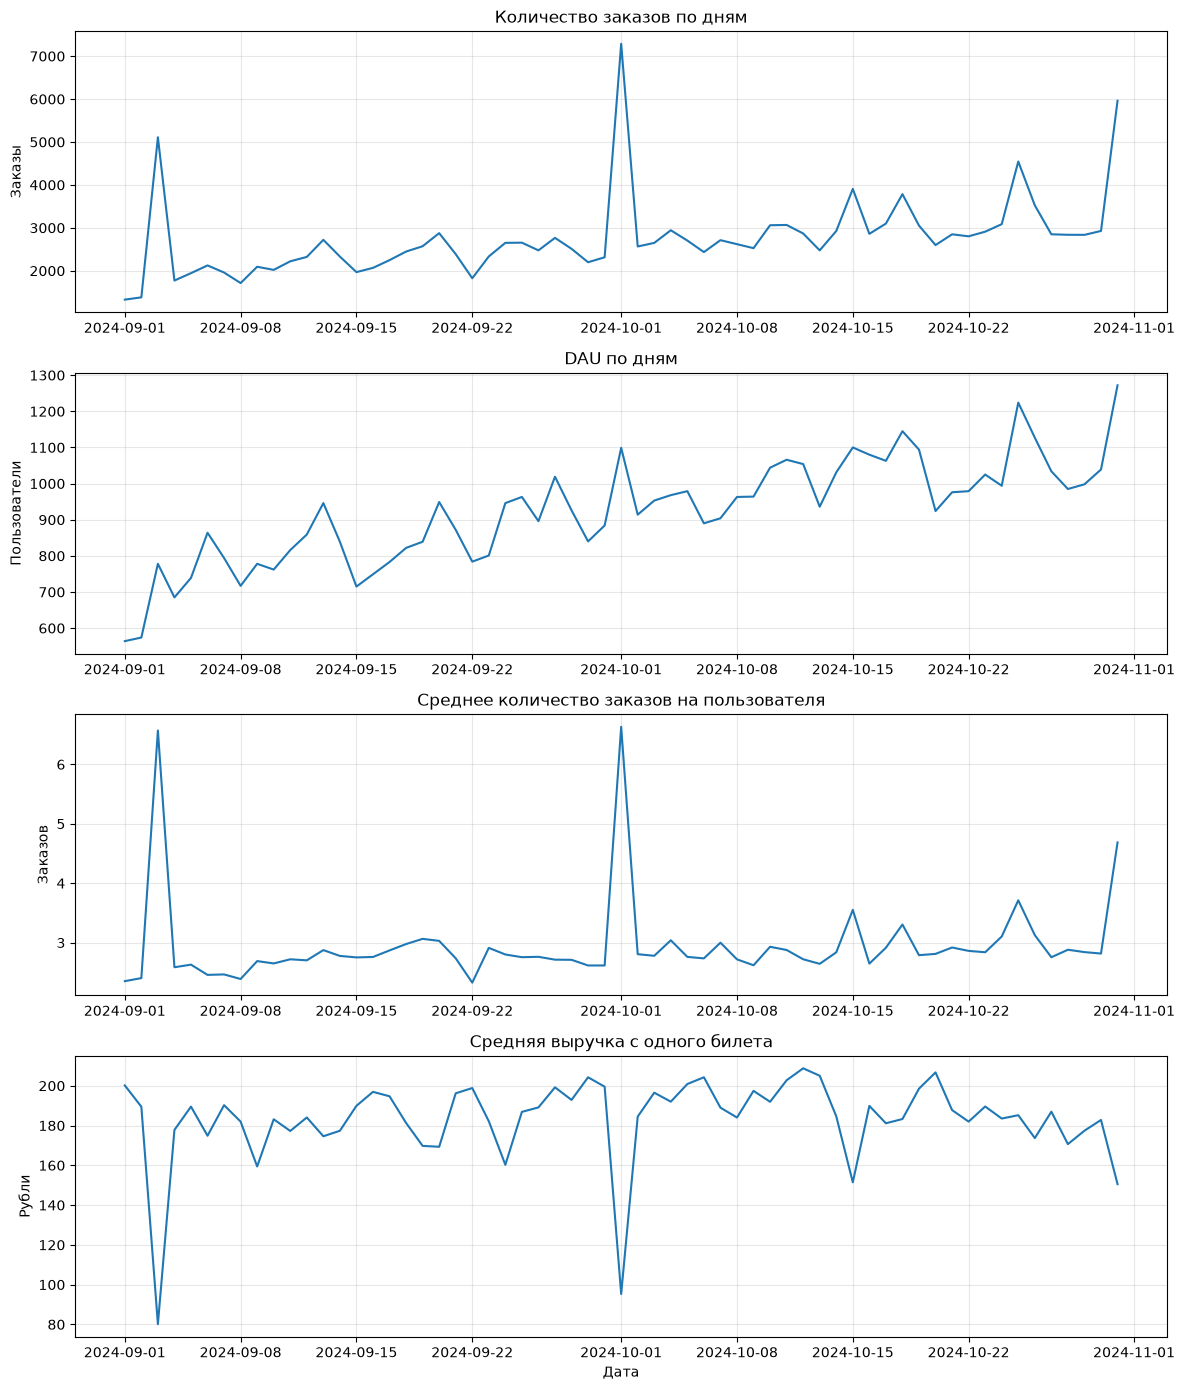

In [53]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14)) #визуализируем показатели

axes[0].plot(
    daily_activity['created_dt_msk'],
    daily_activity['orders_count'])
axes[0].set_title('Количество заказов по дням')
axes[0].set_ylabel('Заказы')
axes[0].grid(alpha=0.3)

axes[1].plot(
    daily_activity['created_dt_msk'],
    daily_activity['dau'])
axes[1].set_title('DAU по дням')
axes[1].set_ylabel('Пользователи')
axes[1].grid(alpha=0.3)

axes[2].plot(
    daily_activity['created_dt_msk'],
    daily_activity['orders_per_user'])
axes[2].set_title('Среднее количество заказов на пользователя')
axes[2].set_ylabel('Заказов')
axes[2].grid(alpha=0.3)

axes[3].plot(
    daily_activity['created_dt_msk'],
    daily_activity['avg_ticket_price'])
axes[3].set_title('Средняя выручка с одного билета')
axes[3].set_ylabel('Рубли')
axes[3].set_xlabel('Дата')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

В течение сентября и октября пользовательская активность в целом растёт. Количество заказов по дням увеличивается к концу периода, при этом наблюдаются отдельные резкие пики. Особенно выделяются начало сентября, начало октября и конец октября.

Показатель DAU также демонстрирует восходящую динамику: число активных пользователей постепенно увеличивается от сентября к концу октября. Это говорит о том, что рост количества заказов связан не только с большей частотой покупок существующих пользователей, но и с увеличением числа активных пользователей.

Среднее число заказов на одного пользователя большую часть периода остаётся относительно стабильным — примерно на уровне 2,5–3 заказов в день, однако в отдельные даты наблюдаются резкие всплески. Наиболее заметные пики совпадают с днями резкого роста общего количества заказов.

Средняя выручка с одного билета колеблется сильнее и не показывает устойчивого восходящего тренда. Большую часть периода показатель находится примерно в диапазоне 170–200 рублей, однако в отдельные дни наблюдаются заметные снижения. Следовательно, рост осенней активности в первую очередь связан с увеличением количества заказов и числа активных пользователей, а не с ростом средней стоимости билета.

In [54]:
weekday_names = { #рассмотрим недельную цикличность
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'}

daily_activity['weekday_num'] = (
    daily_activity['created_dt_msk'].dt.dayofweek)

daily_activity['weekday'] = (
    daily_activity['weekday_num'].map(weekday_names))

daily_activity['day_type'] = daily_activity['weekday_num'].apply(
    lambda x: 'выходной' if x >= 5 else 'будний')

In [55]:
weekday_activity = ( #считаем среднее
    daily_activity
    .groupby('weekday_num')
    .agg(
        orders_count=('orders_count', 'mean'),
        dau=('dau', 'mean'),
        orders_per_user=('orders_per_user', 'mean'),
        avg_ticket_price=('avg_ticket_price', 'mean')))

weekday_activity.index = [
    weekday_names[i] for i in weekday_activity.index]

display(weekday_activity.round(2))

,orders_count,dau,orders_per_user,avg_ticket_price
понедельник,2390.11,853.56,2.78,184.40
вторник,3497.78,934.22,3.72,156.49
среда,2542.33,923.11,2.75,185.27
четверг,3018.44,962.11,3.06,181.79
пятница,3103.25,1022.62,3.00,185.15
суббота,2666.62,960.62,2.76,192.32
воскресенье,2154.22,822.67,2.60,197.57


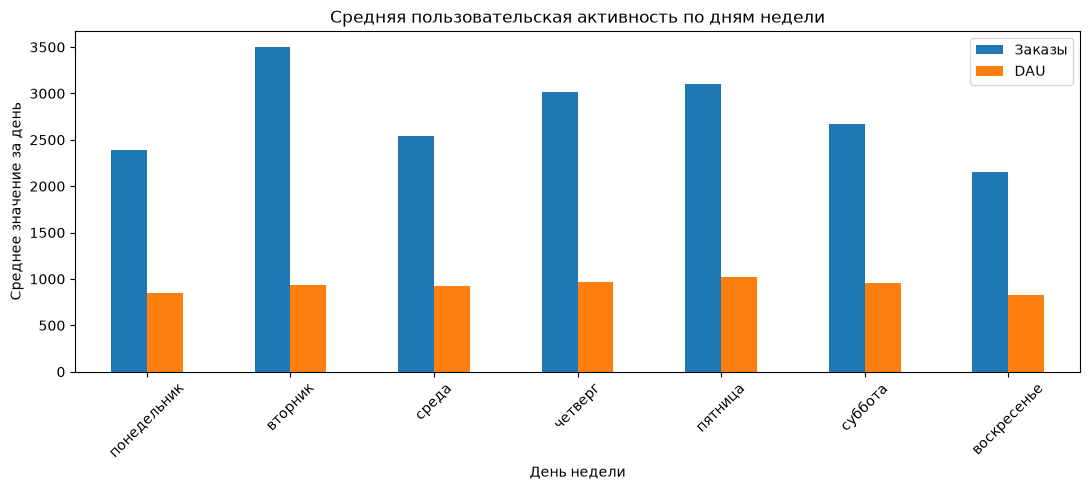

In [56]:
weekday_activity[ #график пользовательской активности
    ['orders_count', 'dau']
].plot(
    kind='bar',
    figsize=(11, 5)
)

plt.title('Средняя пользовательская активность по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее значение за день')
plt.xticks(rotation=45)
plt.legend(['Заказы', 'DAU'])
plt.tight_layout()

plt.show()

Недельная цикличность выражена достаточно заметно. Максимальное среднее количество заказов приходится на вторник — около 3,5 тыс. заказов в день. Высокая активность также наблюдается в четверг и пятницу. Минимальное среднее число заказов фиксируется в воскресенье — около 2,15 тыс.

По DAU наиболее активным днём является пятница — в среднем около 1 023 пользователей, тогда как минимальное значение наблюдается в воскресенье — около 823 пользователей. При этом вторник выделяется самым высоким средним числом заказов на одного пользователя — 3,72, что объясняет высокий объём заказов даже при DAU ниже пятничного.

Средняя выручка с одного билета, напротив, выше в выходные: максимальное значение наблюдается в воскресенье — около 197,6 руб., а минимальное — во вторник, около 156,5 руб. Таким образом, наиболее активные по количеству заказов дни не обязательно совпадают с днями с наиболее высокой средней стоимостью билета.

In [57]:
day_type_activity = ( #сравним показатели в будни и выходные дни
    daily_activity
    .groupby('day_type')
    .agg(
        orders_count=('orders_count', 'mean'),
        dau=('dau', 'mean'),
        orders_per_user=('orders_per_user', 'mean'),
        avg_ticket_price=('avg_ticket_price', 'mean')))

display(day_type_activity.round(2))

,orders_count,dau,orders_per_user,avg_ticket_price
day_type,,,,
будний,2906.00,937.23,3.07,178.47
выходной,2395.35,887.59,2.68,195.10


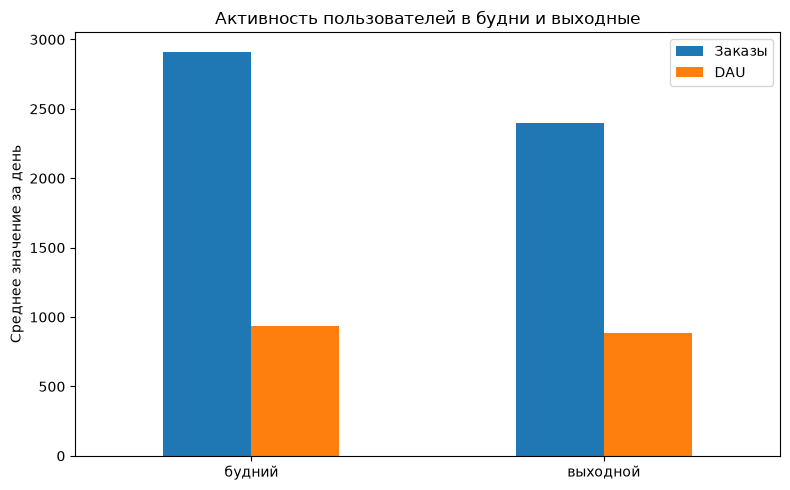

In [58]:
day_type_activity[ #визуализируем
    ['orders_count', 'dau']].plot(
    kind='bar',
    figsize=(8, 5))

plt.title('Активность пользователей в будни и выходные')
plt.xlabel('')
plt.ylabel('Среднее значение за день')
plt.xticks(rotation=0)
plt.legend(['Заказы', 'DAU'])
plt.tight_layout()

plt.show()

В будние дни пользователи в среднем активнее, чем в выходные. Среднее количество заказов составляет около 2 906 в будний день против 2 395 в выходной, то есть в выходные показатель ниже примерно на 17,6%. Средний DAU также выше в будни: 937 пользователей против 888 в выходные.

Среднее число заказов на одного пользователя в будни составляет 3,07, а в выходные — 2,68, что примерно на 12,7% ниже. При этом средняя стоимость одного билета в выходные, наоборот, выше: около 195 руб. против 178 руб. в будни, то есть примерно на 9,3%.

**Промежуточный вывод:**

Осенью 2024 года пользовательская активность постепенно увеличивается: к концу октября растут как количество заказов, так и число активных пользователей. При этом среднее количество заказов на одного пользователя остаётся в целом стабильным, за исключением отдельных всплесков. Это позволяет предположить, что общий рост активности в большей степени связан с расширением числа активных пользователей, а не с постоянным увеличением частоты покупок каждого пользователя.

Также выявлена недельная цикличность. Пользователи активнее совершают заказы в будние дни, особенно во вторник, четверг и пятницу, тогда как в выходные среднее число заказов и DAU ниже. В то же время средняя стоимость одного билета в выходные выше, чем в будни.

С бизнес-точки зрения это означает, что коммуникации и промо, направленные на стимулирование количества покупок, логично усиливать в будние дни, когда пользователи наиболее активны. Выходные при этом могут быть интересны с точки зрения более дорогих покупок, поскольку средняя стоимость одного билета в эти дни выше. Отдельные резкие дневные пики стоит дополнительно учитывать при анализе конкретных событий или промоактивностей, так как они заметно влияют на дневные показатели.

### Анализ регионов и билетных партнёров

In [59]:
# показатели по регионам
region_stats = (
    df.groupby('region_name')
    .agg(
        events_count=('event_id', 'nunique'),
        orders_count=('order_id', 'nunique')))

region_stats['Доля мероприятий'] = (
    region_stats['events_count']
    / df['event_id'].nunique()
    * 100)

region_stats['Доля заказов региона'] = (
    region_stats['orders_count']
    / df['order_id'].nunique()
    * 100)

region_stats = region_stats.sort_values(
    'events_count',
    ascending=False)

display(region_stats.head(10).round(2))

,events_count,orders_count,Доля мероприятий,Доля заказов региона
region_name,,,,
Каменевский регион,5935,89665,26.54,31.17
Североярская область,3800,43738,17.00,15.20
Широковская область,1232,16169,5.51,5.62
Светополянский округ,1075,7502,4.81,2.61
Речиновская область,702,6267,3.14,2.18
Травяная область,683,5036,3.05,1.75
Горицветская область,551,5153,2.46,1.79
Серебринская область,541,5586,2.42,1.94
Яблоневская область,535,6123,2.39,2.13


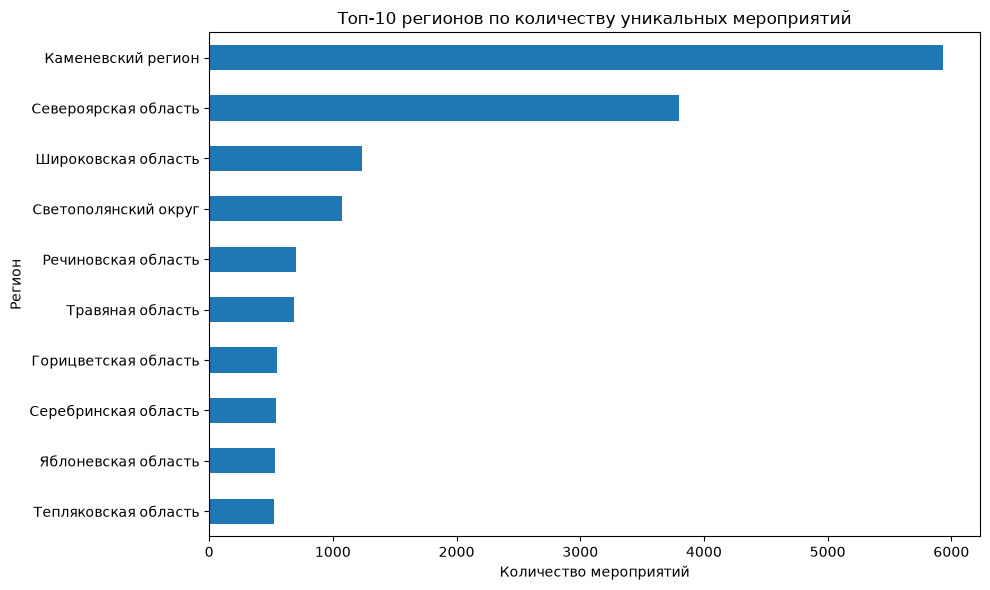

In [60]:
region_stats.head(10)['events_count'].sort_values().plot( #отобразим популярные регионы по количеству меропрятий
    kind='barh',
    figsize=(10, 6))

plt.title('Топ-10 регионов по количеству уникальных мероприятий')
plt.xlabel('Количество мероприятий')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()

Распределение мероприятий по регионам неоднородно. Явным лидером является Каменевский регион: здесь представлено 5 935 уникальных мероприятий, что составляет 26,54% от их общего количества. На этот же регион приходится 89 665 заказов, или 31,17% всех заказов. Второе место занимает Североярская область — 3 800 мероприятий (17,00%) и 43 738 заказов (15,20%).

После двух лидирующих регионов наблюдается заметный разрыв: доля каждого следующего региона по количеству мероприятий не превышает 5,51%. В совокупности Каменевский регион и Североярская область концентрируют около 43,5% всех уникальных мероприятий и 46,4% заказов. Топ-5 регионов обеспечивают 60,42% всех заказов.

Таким образом, предложение мероприятий и спрос заметно сконцентрированы в нескольких регионах, однако распределение не ограничивается одним лидером. Каменевский регион выделяется одновременно и разнообразием афиши, и объёмом пользовательского спроса.

In [61]:
partner_stats = ( #анализ популярности партнеров
    df.groupby('service_name')
    .agg(
        events_count=('event_id', 'nunique'),
        orders_count=('order_id', 'nunique'),
        revenue_rub=('revenue_rub', 'sum')))

partner_stats['Доля заказов'] = (
    partner_stats['orders_count']
    / df['order_id'].nunique()
    * 100)

partner_stats['Доля выручки партнера'] = (
    partner_stats['revenue_rub']
    / df['revenue_rub'].sum()
    * 100)

partner_stats = partner_stats.sort_values(
    'revenue_rub',
    ascending=False)

display(partner_stats.head(10).round(2))

,events_count,orders_count,revenue_rub,Доля заказов,Доля выручки партнера
service_name,,,,,
Билеты без проблем,4247,62832,24255351.60,21.84,16.27
Мой билет,1300,34440,22042364.72,11.97,14.78
Облачко,2335,26402,18588613.86,9.18,12.47
Лови билет!,4867,40800,16670333.48,14.18,11.18
Весь в билетах,855,16410,16494669.19,5.70,11.06
Билеты в руки,3530,40281,13194329.82,14.00,8.85
Край билетов,252,6109,6405689.22,2.12,4.30
Прачечная,1026,10222,4746810.52,3.55,3.18
Дом культуры,272,4412,4358655.99,1.53,2.92


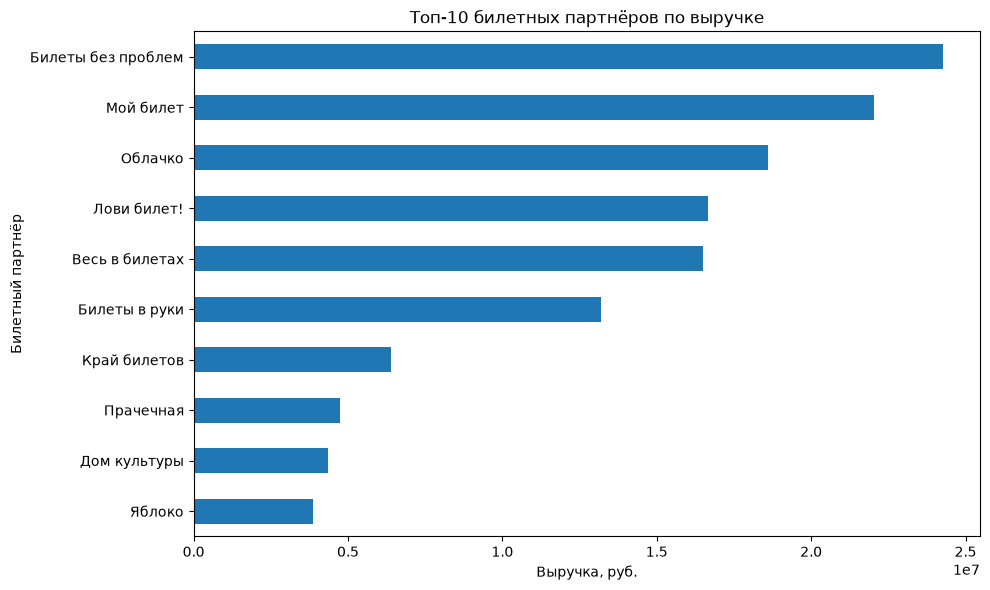

In [62]:
partner_stats.head(10)['revenue_rub'].sort_values().plot( #отобразим популярных партнеров в разрезе выручки
    kind='barh',
    figsize=(10, 6))

plt.title('Топ-10 билетных партнёров по выручке')
plt.xlabel('Выручка, руб.')
plt.ylabel('Билетный партнёр')
plt.tight_layout()
plt.show()

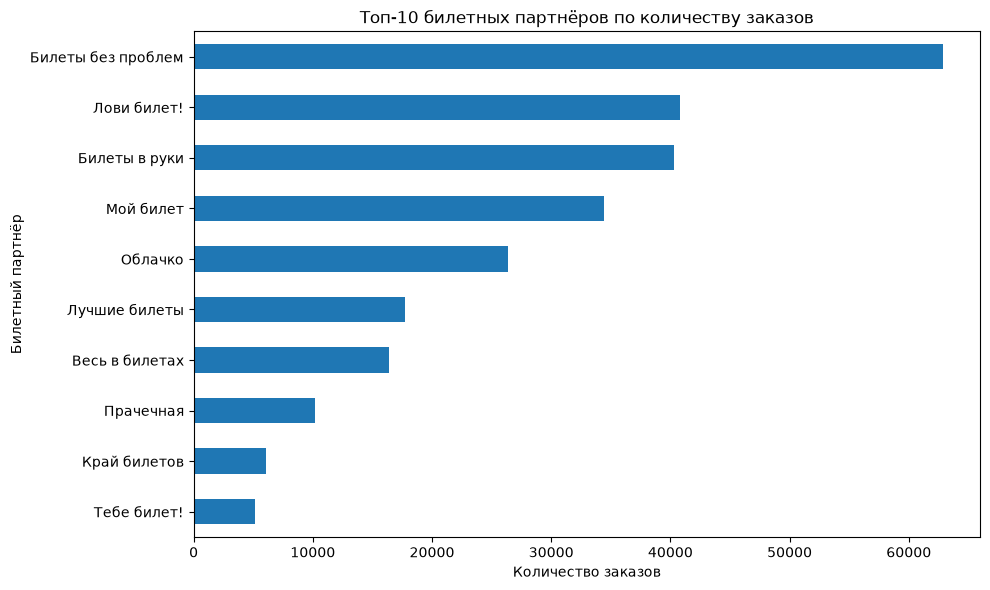

In [63]:
partner_orders_top = partner_stats.sort_values( #отобразим их и в разрезе количества заказов
    'orders_count',
    ascending=False).head(10)

partner_orders_top['orders_count'].sort_values().plot(
    kind='barh',
    figsize=(10, 6))

plt.title('Топ-10 билетных партнёров по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Билетный партнёр')
plt.tight_layout()
plt.show()

Среди билетных партнёров также наблюдается выраженная концентрация. Лидером по выручке и числу обработанных заказов является «Билеты без проблем»: партнёр обработал 62 832 заказа, или 21,84% от общего числа, и сформировал около 24,3 млн руб. выручки — 16,27% общей выручки.

Далее по выручке следуют «Мой билет» — около 22,0 млн руб. (14,78%) и «Облачко» — 18,6 млн руб. (12,47%). При этом рейтинг партнёров по числу заказов отличается от рейтинга по выручке. Например, «Лови билет!» и «Билеты в руки» обрабатывают примерно по 40 тыс. заказов и занимают значительную долю по объёму, но их доля в общей выручке ниже доли заказов. Напротив, у «Мой билет» и особенно «Весь в билетах» доля выручки заметно выше доли заказов.

Это показывает, что большое число заказов не обязательно означает пропорционально высокую выручку: партнёры отличаются не только объёмом продаж, но и денежным вкладом одного заказа.

In [64]:
print( #рассмотрим долю лидирующих (топ-5) партнеров и регионов относительно их общего количества
     'Доля заказов топ-5 регионов:',
    region_stats.nlargest(5, 'orders_count')['Доля заказов региона'].sum().round(2),'%')

print(
    'Доля заказов топ-5 партнёров:',
    partner_stats.nlargest(5, 'orders_count')['Доля заказов'].sum().round(2),'%')

print(
    'Доля выручки топ-5 партнёров:',
    partner_stats.nlargest(5, 'revenue_rub')['Доля выручки партнера'].sum().round(2),'%')

Доля заказов топ-5 регионов: 60.42 %
Доля заказов топ-5 партнёров: 71.17 %
Доля выручки топ-5 партнёров: 65.76 %


**Промежуточный вывод:** 

Распределение мероприятий и заказов по регионам достаточно концентрированное. Основным региональным лидером является Каменевский регион, на который приходится 26,54% уникальных мероприятий и 31,17% заказов. Вместе с Североярской областью два крупнейших региона формируют около 43,5% предложения мероприятий и 46,4% спроса. В целом топ-5 регионов обеспечивают 60,42% всех заказов, поэтому значительная часть пользовательской активности сосредоточена в ограниченном числе регионов.

Среди билетных партнёров концентрация ещё выше: на топ-5 приходится 71,17% заказов и 65,76% общей выручки. Наиболее значимым партнёром является «Билеты без проблем», который лидирует по числу заказов и выручке. При этом лидер по количеству уникальных мероприятий — «Лови билет!», поэтому большое разнообразие событий само по себе не гарантирует максимальную выручку.

С бизнес-точки зрения сервис существенно зависит от нескольких крупных регионов и билетных партнёров. Это делает их приоритетными направлениями для поддержания ассортимента и партнёрских отношений. Одновременно различия между долей заказов и долей выручки показывают, что партнёров важно оценивать не только по объёму продаж: некоторые из них обеспечивают сравнительно более высокий денежный вклад при меньшем количестве заказов. Для дальнейшего развития можно отдельно изучить практики таких партнёров и потенциал менее представленных регионов.

## Статистический анализ данных

In [65]:
autumn = df[df['season'] == 'осень'].copy() #отфильтруем осеннее время года

In [66]:
user_devices = ( #проверка наличия пользователей, которые оформляли заказ с обоих типов устройств
    autumn.groupby('user_id')['device_type_canonical']
    .nunique())

print('Пользователей только с одним типом устройства:',
      (user_devices == 1).sum())

print('Пользователей с обоими типами устройств:',
      (user_devices > 1).sum())

Пользователей только с одним типом устройства: 12560
Пользователей с обоими типами устройств: 3248


При подготовке выборок установлено, что 3 248 пользователей осенью совершали заказы с обоих типов устройств. Включение одного пользователя одновременно в группы mobile и desktop нарушило бы предпосылку независимости наблюдений. Поэтому для статистического анализа оставлены пользователи, которые в течение осеннего периода использовали только один тип устройства.

In [67]:
single_device_users = user_devices[user_devices == 1].index

autumn_single = autumn[
    autumn['user_id'].isin(single_device_users)
].copy()

print(
    'Пользователей для статистического анализа:',
    autumn_single['user_id'].nunique()
)

Пользователей для статистического анализа: 12560


In [68]:
orders_per_user = ( #считаем число заказов каждого пользователя с каждого типа устройства
    autumn_single
    .groupby(['user_id', 'device_type_canonical'])['order_id']
    .nunique()
    .reset_index(name='orders_count'))

mobile_orders = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'mobile',
    'orders_count']

desktop_orders = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'desktop',
    'orders_count']

display(
    orders_per_user
    .groupby('device_type_canonical')['orders_count']
    .describe())

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,1620.0,1.974074,3.060529,1.0,1.0,1.0,2.0,56.0
mobile,10940.0,2.858318,4.096897,1.0,1.0,2.0,3.0,123.0


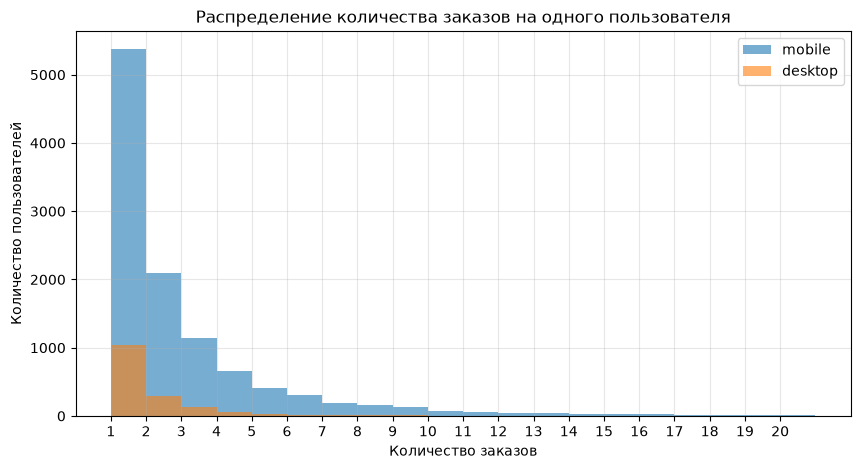

In [69]:
q99_mobile = mobile_orders.quantile(0.99) #отобразим на графике колво заказов на 1 пользователя
q99_desktop = desktop_orders.quantile(0.99) #ограничим вывод 99процентилем для наглядности

max_orders = int(max(q99_mobile, q99_desktop))

bins = range(1, max_orders + 2)

plt.figure(figsize=(10, 5))

plt.hist(
    mobile_orders[mobile_orders <= q99_mobile],
    bins=bins,
    alpha=0.6,
    label='mobile')

plt.hist(
    desktop_orders[desktop_orders <= q99_desktop],
    bins=bins,
    alpha=0.6,
    label='desktop')

plt.title('Распределение количества заказов на одного пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.xticks(range(1, max_orders + 1))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Ограничение по 99-му процентилю использовалось только для визуализации распределений; в статистический тест включались полные выборки.

Формулировки гипотез:

H₀: среднее количество заказов на одного пользователя mobile не выше, чем у пользователей desktop.

H₁: среднее количество заказов на одного пользователя mobile выше, чем у пользователей desktop.

Для проверки гипотез необходимо сравнить средние значения количественных показателей в двух группах — пользователей мобильных и стационарных устройств. В качестве статистического метода выбран t-тест Уэлча для независимых выборок.

В отличие от классического t-теста Стьюдента, тест Уэлча не предполагает равенства дисперсий в сравниваемых группах. Это важно в данном исследовании, поскольку группы mobile и desktop различаются по численности, а распределения пользовательской активности имеют выраженную правостороннюю асимметрию и выбросы. Поэтому предположение об одинаковой дисперсии показателей в группах заранее считать выполненным нельзя.

In [70]:
alpha = 0.05 # проводим тест

result_orders = stats.ttest_ind(
    mobile_orders,
    desktop_orders,
    equal_var=False,
    alternative='greater')

print('Среднее mobile:', mobile_orders.mean())
print('Среднее desktop:', desktop_orders.mean())
print('p-value:', result_orders.pvalue)

if result_orders.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

Среднее mobile: 2.8583180987202925
Среднее desktop: 1.974074074074074
p-value: 7.163336265354689e-25
Отвергаем нулевую гипотезу


Результат проверки первой гипотезы. Среднее количество заказов на одного пользователя mobile составляет 2,86, тогда как у пользователей desktop — 1,97. Таким образом, в выборке пользователи mobile совершают в среднем примерно на 44,8% больше заказов.

Полученное p-value = 7.16e-25, что значительно меньше уровня статистической значимости α = 0.05. Поэтому нулевая гипотеза отвергается. Есть статистически значимые основания утверждать, что среднее количество заказов на одного пользователя mobile выше, чем у пользователей desktop.

In [71]:
days_per_user = ( #подсчет среднего времени между заказами пользователя
    autumn_single
    .dropna(subset=['days_since_prev'])
    .groupby(['user_id', 'device_type_canonical'])['days_since_prev']
    .mean()
    .reset_index(name='mean_days_since_prev'))

mobile_days = days_per_user.loc[
    days_per_user['device_type_canonical'] == 'mobile',
    'mean_days_since_prev']

desktop_days = days_per_user.loc[
    days_per_user['device_type_canonical'] == 'desktop',
    'mean_days_since_prev']

display(
    days_per_user
    .groupby('device_type_canonical')['mean_days_since_prev']
    .describe())

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,894.0,31.361372,36.560749,0.0,0.000000,16.0,53.0,146.0
mobile,7055.0,25.250757,30.207499,0.0,2.851852,14.0,36.0,148.0


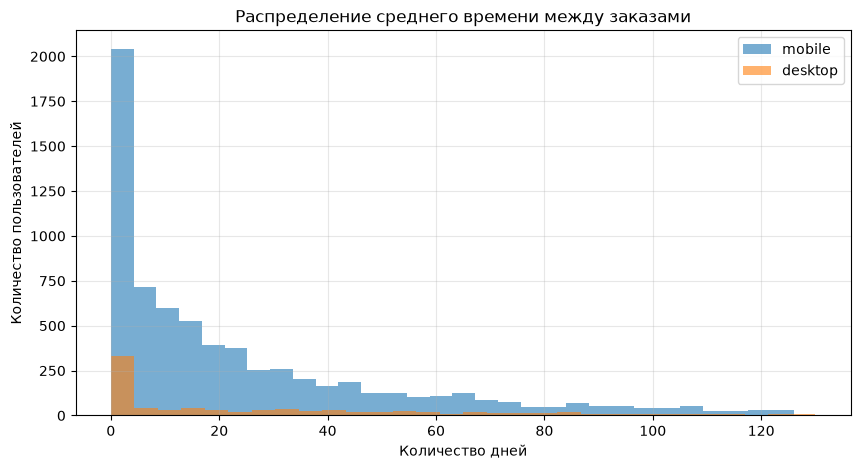

In [72]:
q99_mobile_days = mobile_days.quantile(0.99) #визуализируем
q99_desktop_days = desktop_days.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    mobile_days[mobile_days <= q99_mobile_days],
    bins=30,
    alpha=0.6,
    label='mobile')

plt.hist(
    desktop_days[desktop_days <= q99_desktop_days],
    bins=30,
    alpha=0.6,
    label='desktop')

plt.title('Распределение среднего времени между заказами')
plt.xlabel('Количество дней')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

H₀: среднее время между заказами пользователей mobile не выше, чем у пользователей desktop.
H₁: среднее время между заказами пользователей mobile выше, чем у пользователей desktop.

Для проверки второй гипотезы также используется односторонний t-тест Уэлча при уровне статистической значимости 0,05.

In [73]:
result_days = stats.ttest_ind(
    mobile_days,
    desktop_days,
    equal_var=False,
    alternative='greater')

print('Среднее mobile:', mobile_days.mean())
print('Среднее desktop:', desktop_days.mean())
print('p-value:', result_days.pvalue)

if result_days.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

Среднее mobile: 25.250757
Среднее desktop: 31.361372
p-value: 0.99999905
Не удалось отвергнуть нулевую гипотезу


Результат проверки второй гипотезы. Среднее время между заказами пользователей mobile составляет 25,25 дня, тогда как у пользователей desktop — 31,36 дня. То есть в наблюдаемой выборке интервал между заказами у mobile не выше, а, напротив, примерно на 6,1 дня меньше.

Полученное p-value ≈ 1.00, что значительно превышает уровень значимости α = 0.05. Поэтому нулевую гипотезу отвергнуть не удалось. Статистических оснований утверждать, что среднее время между заказами пользователей mobile выше, чем у пользователей desktop, нет. Более того, описательные статистики показывают противоположное направление различий: у пользователей mobile средний интервал между заказами меньше.

**Промежуточный вывод:**

Статистический анализ частично подтвердил предположения продуктовой команды о большей активности пользователей мобильных устройств. Пользователи mobile совершают в среднем 2,86 заказа против 1,97 у пользователей desktop, и это различие статистически значимо. Первая гипотеза подтверждается.

Вторая гипотеза не получила подтверждения. Среднее время между заказами пользователей mobile составляет 25,25 дня против 31,36 дня у desktop.

С бизнес-точки зрения мобильный сегмент выглядит более активным сразу по двум поведенческим характеристикам: пользователи совершают больше заказов и имеют меньший средний интервал между покупками. Это делает мобильный канал особенно важным для удержания и повторных продаж. При этом вывод относится только к пользователям, которые в течение осеннего периода использовали один тип устройства, поскольку пользователи обоих каналов были исключены для обеспечения независимости сравниваемых выборок.

In [74]:
avg_check = ( #добавим данные о средней выручке с заказа для вывода
    df.groupby('season')['revenue_rub']
    .mean()
    .reindex(['лето', 'осень']))

check_change = (
    (avg_check['осень'] / avg_check['лето'] - 1) * 100)

print(avg_check.round(2))
print(f'Изменение среднего чека: {check_change:.2f}%')

season
лето     565.35
осень    485.06
Name: revenue_rub, dtype: float64
Изменение среднего чека: -14.20%


## Общий вывод

В проекте были проанализированы данные о заказах билетов Яндекс Афиши за июнь–октябрь 2024 года, информация о мероприятиях, регионах и площадках, а также курс казахстанского тенге для приведения денежных показателей к рублям. После предобработки, удаления дубликатов, обработки выбросов и объединения данных в итоговом датасете осталось 287 694 заказа — около 98,9% исходного объёма.

Исследование показало выраженный сезонный рост спроса: количество заказов увеличилось с 34,2 тыс. в июне до 99,3 тыс. в октябре, причём наиболее заметное ускорение начинается в сентябре. Концерты остаются наиболее востребованной категорией, хотя их доля осенью снизилась с 42,61% до 37,19%. Одновременно увеличилась доля театральных мероприятий — с 20,10% до 25,35% — и особенно спортивных: с 2,52% до 11,20%. Таким образом, осенью растёт не только общий объём спроса, но и меняется его структура.

При росте количества заказов денежные показатели не демонстрируют аналогичной динамики. Средняя выручка с заказа снизилась с 565,35 руб. летом до 485,06 руб. осенью — на 14,20%. Средняя выручка с одного билета также снизилась в ряде крупных категорий: у театра на 17,82%, ёлок на 15,42% и концертов на 12,02%. Рост наблюдался только у стендапа (+5,77%) и выставок (+4,85%). Следовательно, осенний рост спроса связан прежде всего с увеличением объёма продаж, а не с ростом выручки на один заказ или билет.

Анализ осенней пользовательской активности показал рост количества заказов и DAU к концу октября. При этом выражена недельная цикличность: в будни совершается в среднем около 2 906 заказов против 2 395 в выходные, а DAU также выше в будние дни. В то же время средняя стоимость одного билета в выходные выше — около 195 руб. против 178 руб. в будни.

Спрос и предложение заметно сконцентрированы географически. Лидером является Каменевский регион: на него приходится 26,54% уникальных мероприятий и 31,17% заказов. Топ-5 регионов в совокупности обеспечивают 60,42% всех заказов. Среди билетных партнёров лидирует «Билеты без проблем» — 62 832 заказа и около 24,3 млн руб. выручки. На топ-5 партнёров приходится 71,17% заказов и 65,76% общей выручки, что указывает на высокую концентрацию бизнеса у нескольких крупных партнёров.

Статистический анализ подтвердил только первую из двух проверяемых гипотез. Пользователи mobile совершают в среднем 2,86 заказа против 1,97 у desktop, и различие статистически значимо (p-value < 0,05). Гипотеза о большем времени между заказами у mobile не подтвердилась: средний интервал составляет 25,25 дня у mobile против 31,36 дня у desktop.

### Рекомендации

В первую очередь стоит учитывать выраженную осеннюю сезонность при планировании ассортимента и маркетинговых активностей. Осенью имеет смысл усиливать продвижение спортивных и театральных мероприятий, спрос на которые заметно увеличивается, сохраняя при этом внимание к концертам как крупнейшей категории.

Особое внимание стоит уделять мобильному каналу: около 80% заказов совершается с мобильных устройств, а статистический анализ показывает более высокую активность mobile-пользователей. Поэтому мобильные коммуникации, персональные рекомендации и механики повторных покупок могут быть приоритетным направлением развития.

Для стимулирования количества покупок маркетинговые активности целесообразно усиливать в будние дни, когда выше число заказов и DAU. В выходные можно делать больший акцент на более дорогих предложениях, поскольку средняя стоимость билета в эти дни выше.

Наконец, высокая концентрация заказов у нескольких регионов и партнёров требует одновременно двух направлений работы: поддерживать ключевых лидеров и развивать менее представленные регионы и партнёров для снижения зависимости от ограниченного числа источников продаж. При оценке партнёров важно учитывать не только объём заказов, но и их вклад в выручку и широту ассортимента.